<a href="https://colab.research.google.com/github/nahlarashad/Smart-Object-Detection-System-using-YOLO/blob/main/yolo_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.4 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("Model loaded successfully")

Model loaded successfully


In [4]:
from google.colab import files
uploaded = files.upload()

Saving image.jpg to image.jpg



image 1/1 /content/image.jpg: 640x448 1 person, 3 cars, 1 skateboard, 493.6ms
Speed: 20.2ms preprocess, 493.6ms inference, 67.8ms postprocess per image at shape (1, 3, 640, 448)


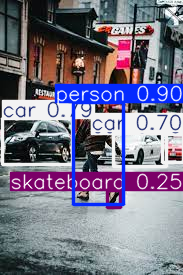

In [6]:
results = model("image.jpg")

results[0].show()

In [7]:
boxes = results[0].boxes
classes = boxes.cls.tolist()

names = model.names

# count all objects
total_objects = len(classes)

# count specific object (مثلاً person)
person_count = 0

for cls in classes:
    if names[int(cls)] == "person":
        person_count += 1

print("Total objects:", total_objects)
print("Number of persons:", person_count)

Total objects: 5
Number of persons: 1


In [8]:
from collections import Counter

labels = [names[int(cls)] for cls in classes]

counts = Counter(labels)

print(counts)

Counter({'car': 3, 'person': 1, 'skateboard': 1})


In [9]:
from google.colab import files
uploaded = files.upload()


Saving cctv052x2004080517x01661.avi to cctv052x2004080517x01661.avi



0: 480x640 7 cars, 1 bus, 202.1ms
Speed: 4.0ms preprocess, 202.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


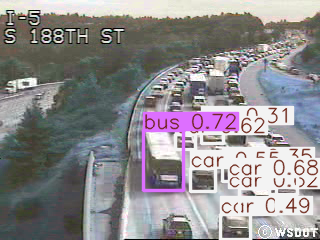

In [15]:
import cv2
from ultralytics import YOLO
from IPython.display import display, clear_output
import PIL.Image

model = YOLO("yolov8n.pt")

video_path = "cctv052x2004080517x01661.avi"
cap = cv2.VideoCapture(video_path)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated_frame = results[0].plot()


    display(PIL.Image.fromarray(annotated_frame))
    clear_output(wait=True)

cap.release()

In [17]:
import cv2
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

video_path = "cctv052x2004080517x01661.avi"
cap = cv2.VideoCapture(video_path)

# video properties
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# save output
out = cv2.VideoWriter("output.mp4",
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps,
                      (width, height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated_frame = results[0].plot()

    out.write(annotated_frame)

cap.release()
out.release()

print("Video saved")


0: 480x640 16 cars, 1 truck, 302.8ms
Speed: 4.7ms preprocess, 302.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 19 cars, 1 bus, 297.7ms
Speed: 3.5ms preprocess, 297.7ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 19 cars, 2 buss, 285.7ms
Speed: 6.3ms preprocess, 285.7ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 20 cars, 2 buss, 302.1ms
Speed: 7.2ms preprocess, 302.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 20 cars, 3 buss, 338.6ms
Speed: 6.2ms preprocess, 338.6ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 17 cars, 315.8ms
Speed: 7.5ms preprocess, 315.8ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 16 cars, 1 truck, 277.5ms
Speed: 7.9ms preprocess, 277.5ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 17 cars, 2 buss, 1 truck, 206.0ms
Speed: 7.3ms pre

In [18]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>